# Inference with Pretrained SAE (No Training)

Use the pretrained sparse autoencoder checkpoints in `checkpoints/` (either `best_model.pt` or `pruned_model.pt`) to reproduce the post-training analyses from the tutorial: load GPT-2, run the SAE on new text, and visualize feature behaviors.

## What this notebook does
- Loads GPT-2 and the pretrained SAE (choose best vs pruned).
- (Optional) Loads `activations.pt` to reuse the exact normalization stats from your original training.
- Collects activations for new text, runs them through the SAE, and mirrors the tutorial plots: feature rankings, correlation heatmap, reconstruction quality, and feature dashboards.

If `activations.pt` is unavailable, we can still run inference; normalization will be approximate (using only the new texts).

In [1]:
import sys, os
from pathlib import Path
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# Add src to path
sys.path.append('..\src')

from data_collection import GPT2ActivationCollector
from sae_model import SparseAutoencoder
from interpretation import FeatureAnalyzer

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

<>:8: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:8: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\Arnob\AppData\Local\Temp\ipykernel_8676\2585544005.py:8: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  sys.path.append('..\src')


Using device: cpu


In [2]:
# Configuration
CHECKPOINT_DIR = Path('../checkpoints')
SAE_CHECKPOINT = CHECKPOINT_DIR / 'pruned_model.pt'  # swap to 'best_model.pt' if you prefer the full model
OPTIONAL_STATS = CHECKPOINT_DIR / 'activations.pt'   # set to your activations file if available
MODEL_NAME = 'gpt2'
TARGET_LAYER = 8
MAX_LENGTH = 128
BATCH_SIZE = 8
TOP_K = 5

In [3]:
def load_sae_from_checkpoint(path: Path, device: str = 'cpu'):
    ckpt = torch.load(path, map_location=device)
    # Hyperparameters may live in different keys depending on how the file was produced
    hyper = ckpt.get('hyperparameters', {}) if isinstance(ckpt, dict) else {}
    d_model = hyper.get('d_model', ckpt.get('d_model'))
    d_hidden = hyper.get('d_hidden', ckpt.get('d_hidden'))
    l1_coeff = hyper.get('l1_coeff', ckpt.get('l1_coeff', 3e-4))
    if d_model is None or d_hidden is None:
        raise ValueError('Checkpoint missing d_model or d_hidden; please verify the file.')
    sae = SparseAutoencoder(
        d_model=int(d_model),
        d_hidden=int(d_hidden),
        l1_coeff=float(l1_coeff),
        use_tied_weights=False,
        use_pre_bias=True,
        normalize_decoder=True
    ).to(device)
    sae.load_state_dict(ckpt['model_state_dict'])
    sae.eval()
    meta = {
        'd_model': d_model,
        'd_hidden': d_hidden,
        'l1_coeff': l1_coeff,
        'source_keys': list(ckpt.keys())
    }
    return sae, meta

sae, sae_meta = load_sae_from_checkpoint(SAE_CHECKPOINT, device=device)
print('Loaded SAE from', SAE_CHECKPOINT)
print(sae_meta)

Loaded SAE from ..\checkpoints\pruned_model.pt
{'d_model': 768, 'd_hidden': 8707, 'l1_coeff': 0.0003, 'source_keys': ['model_state_dict', 'd_model', 'd_hidden', 'l1_coeff', 'keep_indices', 'dead_threshold', 'freq_threshold']}


In [4]:
# Load GPT-2 and activation collector for the target layer
collector = GPT2ActivationCollector(
    model_name=MODEL_NAME,
    layer_index=TARGET_LAYER,
    device=device
)
tokenizer = collector.tokenizer  # reuse tokenizer

analyzer = FeatureAnalyzer(sae=sae, tokenizer=tokenizer, device=device)
print('Collector and analyzer ready')

Loading GPT-2 model: gpt2
Target layer: 8
Device: cpu


The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Hidden size: 768
Collector and analyzer ready


In [5]:
# Optional: load normalization stats from a saved activations tensor
norm_stats = None
if OPTIONAL_STATS.exists():
    acts = torch.load(OPTIONAL_STATS, map_location='cpu')
    # If the tensor is large, compute stats lazily without keeping everything on GPU
    if isinstance(acts, torch.Tensor):
        norm_stats = {
            'mean': acts.mean(dim=0),
            'std': acts.std(dim=0).clamp_min(1e-6)
        }
        print(f'Loaded normalization stats from {OPTIONAL_STATS}')
    elif isinstance(acts, dict) and 'activations' in acts:
        t = acts['activations']
        norm_stats = {
            'mean': t.mean(dim=0),
            'std': t.std(dim=0).clamp_min(1e-6)
        }
        print(f'Loaded normalization stats from activations dict in {OPTIONAL_STATS}')
    else:
        print('activations.pt format not recognized; skipping normalization preload')
else:
    print('No activations stats file found; will use on-the-fly stats from new texts')

No activations stats file found; will use on-the-fly stats from new texts


In [6]:
def collect_and_normalize(texts, batch_size=BATCH_SIZE, max_length=MAX_LENGTH, norm_stats=norm_stats):
    activations = collector.collect_activations(
        texts=texts,
        batch_size=batch_size,
        max_length=max_length
    )
    if norm_stats is None:
        mean = activations.mean(dim=0)
        std = activations.std(dim=0).clamp_min(1e-6)
    else:
        mean = norm_stats['mean']
        std = norm_stats['std']
    activations_norm = (activations - mean) / std
    return activations, activations_norm

def summarize_features_per_text(texts, activations_norm):
    # Split activations back per text using attention masks is complex;
    # here we aggregate over tokens sequentially per input length.
    features_per_text = []
    start = 0
    for text in texts:
        # Re-tokenize to know how many tokens were kept after padding/truncation
        tokens = tokenizer(text, truncation=True, max_length=MAX_LENGTH, return_tensors='pt')
        seq_len = int(tokens['input_ids'].shape[1])
        end = start + seq_len
        slice_feats = sae.encode(activations_norm[start:end].to(device)).detach().cpu()
        features_per_text.append({
            'feature_mean': slice_feats.mean(dim=0),
            'feature_max': slice_feats.max(dim=0).values
        })
        start = end
    return features_per_text

print('Helper functions ready')

Helper functions ready


In [7]:
# Example texts (edit freely)
test_texts = [
    'CAT',
    'cat',
    'CaT',
    'cAt',
    'CAt',
]

raw_acts, norm_acts = collect_and_normalize(test_texts)
print('Raw activations shape:', raw_acts.shape)
print('Normalized activations shape:', norm_acts.shape)


Collected 9 activation vectors
Shape: torch.Size([9, 768])
Mean activation: 2.7280
Std activation: 83.6555
Raw activations shape: torch.Size([9, 768])
Normalized activations shape: torch.Size([9, 768])


In [8]:
# Encode and list top-k features per text (using mean over that text's tokens)
summaries = summarize_features_per_text(test_texts, norm_acts)
for text, summary in zip(test_texts, summaries):
    mean_feats = summary['feature_mean']
    top_vals, top_idx = torch.topk(mean_feats, k=TOP_K)
    print(f"\nText: {text}")
    for idx, val in zip(top_idx, top_vals):
        print(f"  Feature {idx.item()}: {val.item():.4f}")



Text: CAT
  Feature 6445: 4.8750
  Feature 2056: 2.5691
  Feature 6512: 2.3279
  Feature 1221: 2.1512
  Feature 6821: 1.7196

Text: cat
  Feature 6821: 3.5999
  Feature 5932: 3.5066
  Feature 1320: 2.4530
  Feature 4423: 2.1071
  Feature 5201: 2.0367

Text: CaT
  Feature 982: 3.8505
  Feature 5344: 3.0505
  Feature 6821: 2.9834
  Feature 2056: 2.7501
  Feature 6512: 2.6868

Text: cAt
  Feature 5755: 5.0107
  Feature 6512: 2.4471
  Feature 8403: 1.8264
  Feature 6821: 1.6596
  Feature 6569: 1.6541

Text: CAt
  Feature 5755: 4.0545
  Feature 6512: 2.3295
  Feature 1221: 2.1063
  Feature 8403: 2.0616
  Feature 1934: 1.8929


In [ ]:
# # Feature correlation heatmap on the normalized activations
# corr, feature_indices = analyzer.analyze_feature_correlations(norm_acts, top_k=50)
# plt.figure(figsize=(10, 8))
# sns.heatmap(
#     corr.numpy(),
#     cmap='RdBu_r',
#     center=0, vmin=-1, vmax=1,
#     xticklabels=feature_indices.numpy(),
#     yticklabels=feature_indices.numpy()
# )
# plt.title('Feature Correlations (Top 50 by mean activation)')
# plt.xlabel('Feature index')
# plt.ylabel('Feature index')
# plt.tight_layout()
# plt.show()

In [10]:
# Reconstruction quality on the normalized activations
metrics = analyzer.get_reconstruction_quality(norm_acts)
print('Reconstruction quality:')
for k, v in metrics.items():
    print(f"  {k}: {v:.6f}")


Reconstruction quality:
  mse: 0.087591
  cosine_similarity: 0.939488
  explained_variance: 0.922212
  mean_l1: 318.597473
  feature_density: 0.110345


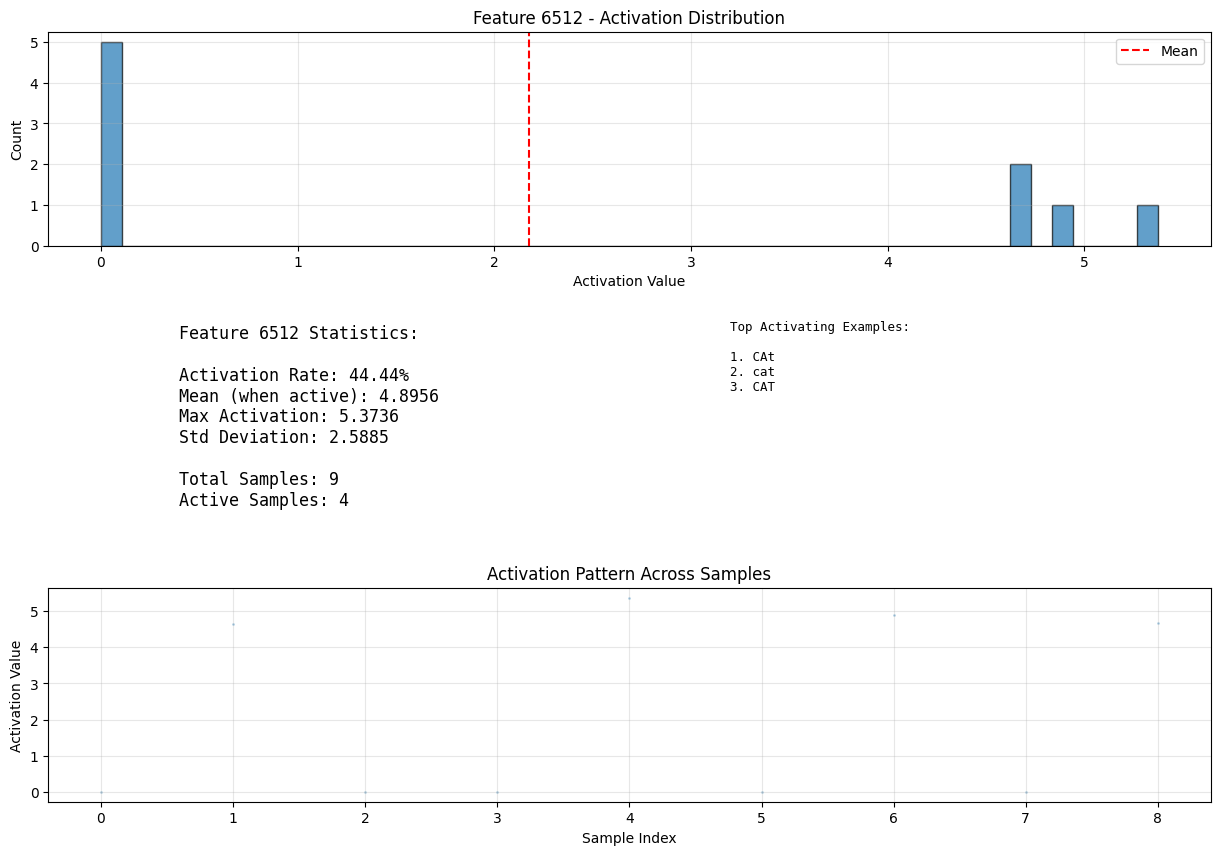

In [18]:
# Feature dashboard for a chosen feature index
feature_idx = 6512  # change to any interesting feature
analyzer.create_feature_dashboard(norm_acts, test_texts, feature_idx)

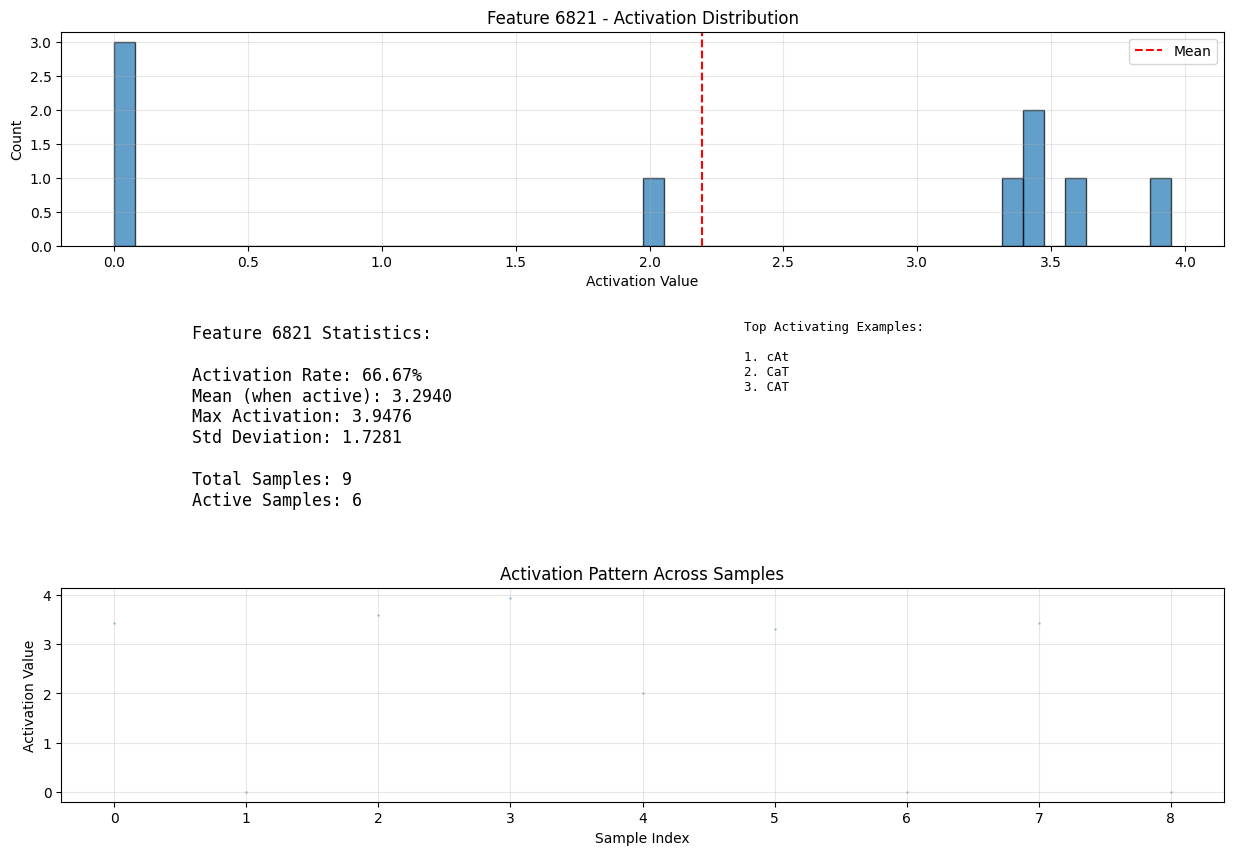

In [17]:
# Feature dashboard for a chosen feature index
feature_idx = 6821  # change to any interesting feature
analyzer.create_feature_dashboard(norm_acts, test_texts, feature_idx)